In [12]:

import seaborn as sns

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, confusion_matrix

In [13]:
tipsdf = sns.load_dataset('tips')
tipsdf.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [14]:
sex_bin = pd.factorize(tipsdf['sex'])
tipsdf['sex_bin'] = sex_bin[0]
tipsdf.head(2)

,total_bill,tip,sex,smoker,day,time,size,sex_bin
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1


In [15]:
X = tipsdf[['total_bill']]
y = tipsdf['sex_bin']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

model_knn = KNeighborsClassifier()
model_nb_clf = GaussianNB()

model_knn.fit(X_train, y_train)
model_nb_clf.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)
y_pred_nb_clf = model_nb_clf.predict(X_test)


In [17]:
cr_knn = classification_report(y_test,y_pred_knn)
print('------------------------K-NN-------------------------')
print(cr_knn)

cr_nb_clf = classification_report(y_test,y_pred_nb_clf)
print('--------------Naive Bayes Classification--------------')
print(cr_nb_clf)


------------------------K-NN-------------------------
              precision    recall  f1-score   support

           0       0.43      0.45      0.44        22
           1       0.68      0.67      0.68        39

    accuracy                           0.59        61
   macro avg       0.56      0.56      0.56        61
weighted avg       0.59      0.59      0.59        61

--------------Naive Bayes Classification--------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.64      1.00      0.78        39

    accuracy                           0.64        61
   macro avg       0.32      0.50      0.39        61
weighted avg       0.41      0.64      0.50        61



c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [18]:
cm_nb = confusion_matrix(y_test, y_pred_nb_clf)
print(cm_nb)

[[ 0 22]
 [ 0 39]]


<Axes: >

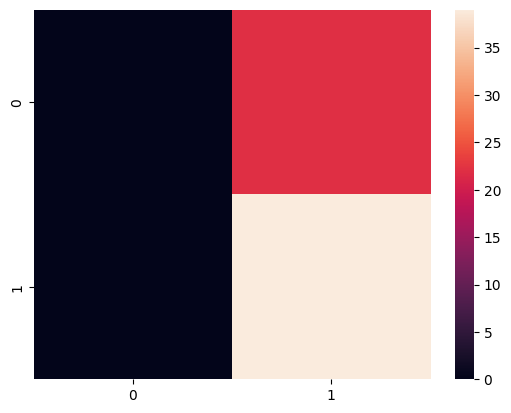

In [19]:
sns.heatmap(cm_nb) # proof of model doing good